# Importações

In [ ]:
import os
import pandas as pd
import re

# Configurações

In [ ]:
path = "/content/dataset_pre_processado.csv"

# Leitura dos dados

In [ ]:
df = pd.read_csv(path)

PARA TODAS AS ESTRATÉGIAS:
- 'classe': A resposta do modelo (1 = Fake News, 0 = Notícia Verdadeira)

IDENTIFICAÇÃO:
- 'id_arquivo': Nome original do arquivo .txt (Para rastreabilidade)

# Colunas para cada estrategia

## ESTRATÉGIA 1: Regras Heurística

In [ ]:
colunas_estrategia_1 = [
    'pct_maiusculas',           # Proporção de letras maiúsculas no texto
    'qtd_pontuacao_expressiva', # Contagem total de exclamações (!) e interrogações (?)
    'razao_titulo_corpo',       # Razão de tamanho entre o título e o corpo da notícia
    'comprimento_texto',        # Tamanho total do texto em palavras
    'titulo',                   # Usar para buscar listas de palavras "clickbait"
    'corpo_noticia'             # Usar para buscar termos sem fonte (ex: "segundo fontes")
]

##Machine Learning Clássico

In [ ]:
colunas_estrategia_2 = [
    'texto_limpo_ml'   # USAR APENAS ESSA PARA VETORIZAR.
                       # O texto aqui já está em minúsculas, lematizado,
                       # e sem stopwords ou pontuação.
]
# Para quem for fazer a estrategia 2:  numéricas da Estratégia 1 ao vetor TF-IDF final para tentar melhorar o F1-Score!

## Transformers (BERTimbau)

In [ ]:
colunas_estrategia_3 = [
    'texto_limpo_bert' #  USAR APENAS ESSA PARA O TOKENIZADOR WORDPIECE.
                       # O texto aqui manteve a pontuação, as stopwords e as
                       # letras maiúsculas originais, essenciais para o contexto do BERT.
]

# Desenvolvimento das estratégias

## Estratégia 1: Baseada em heurísticas

In [ ]:
import numpy as np
import re

def classificador_heuristico(row, threshold=0.4):
    score = 0.0
    # Refinando pesos para melhorar a precisão (focar em sinais mais fortes)
    pesos = {
        'maiusculas': 0.25,
        'pontuacao': 0.25,
        'clickbait': 0.40,
        'razao_corpo': 0.10,
        'falta_fontes': 0.30
    }

    # 1. Maiúsculas (> 12% é um sinal mais forte de sensacionalismo)
    if row['pct_maiusculas'] > 0.12:
        score += pesos['maiusculas']

    # 2. Pontuação expressiva (> 1 no título/corpo)
    if row['qtd_pontuacao_expressiva'] > 1:
        score += pesos['pontuacao']

    # 3. Clickbait (Lista focada em termos de alto impacto)
    termos_clickbait = r'(CHOCANTE|BOMBA|REVELADO|ABSURDO|ESCÂNDALO|MISTÉRIO|PERIGO|VEXAME|ACABOU)'
    if re.search(termos_clickbait, str(row['titulo']).upper()):
        score += pesos['clickbait']

    # 4. Razão título/corpo (> 15%)
    if row['razao_titulo_corpo'] > 0.15:
        score += pesos['razao_corpo']

    # 5. Falta de fontes (Aumentado o peso para precisão)
    corpo = str(row['corpo_noticia']).lower()
    fontes_confiaveis = r'("|segundo o|conforme|disse|afirmou|declarou|ministerio|policia|oficial)'
    if not re.search(fontes_confiaveis, corpo):
        score += pesos['falta_fontes']

    classe_predita = 1 if score >= threshold else 0
    return pd.Series([score, classe_predita], index=['score_final', 'predicao_heuristica'])

# Execução separada da avaliação
res_estrategia_1 = df.apply(lambda r: classificador_heuristico(r, threshold=0.4), axis=1)
df_e1 = pd.concat([df[colunas_estrategia_1 + ['id_arquivo', 'classe']], res_estrategia_1], axis=1)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Distribuição de Densidade (KDE)
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_e1, x='score_final', hue='classe', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('Distribuição de Scores (KDE)\nReal (0) vs Fake (1)')
plt.xlabel('Score Heurístico Final')
plt.ylabel('Densidade')

# Plot 2: Boxplot para ver quartis e outliers
plt.subplot(1, 2, 2)
sns.boxplot(data=df_e1, x='classe', y='score_final', palette='viridis', hue='classe', legend=False)
plt.title('Boxplot de Scores por Classe')
plt.xlabel('Classe (0=Real, 1=Fake)')
plt.ylabel('Score Final')

plt.tight_layout()
plt.show()

### Análise Qualitativa: Notícias com Maior Score Heurístico
Vamos observar os textos que o sistema considerou mais 'suspeitos' com base nas regras de pontuação, maiúsculas e palavras sensacionalistas.

In [ ]:
from sklearn.metrics import classification_report

# Bloco de Avaliação Separado
print("Avaliação de Performance - Estratégia 1 (Heurísticas Refinadas):")
print(classification_report(df_e1['classe'], df_e1['predicao_heuristica']))

# Top notícias para análise qualitativa
display(df_e1.sort_values(by='score_final', ascending=False)[['titulo', 'score_final', 'predicao_heuristica', 'classe']].head(5))

## Estratégia 2: Machine Learning Clássico


### Experimento A: Classificação Baseada Apenas em Texto (TF-IDF)
Nesta fase, transformaremos o texto limpo em matrizes numéricas e testaremos três algoritmos clássicos.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import numpy as np

# 1. Preparação dos dados para o Experimento A
X_text = df['texto_limpo_ml'].fillna('')
y = df['classe']

# Divisão Treino/Teste
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

# 2. Vetorização TF-IDF (Unigramas, Bigramas e Trigamas)
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Shape da matriz TF-IDF: {X_train_tfidf.shape}")

#### Treinamento com Grid Search - Experimento A

In [ ]:
# Definindo os modelos e parâmetros para o GridSearch
models_params = [
    {
        'name': 'Naive Bayes',
        'model': MultinomialNB(),
        'params': {'alpha': [0.1, 0.5, 1.0]}
    },
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    {
        'name': 'SVM',
        'model': SVC(),
        'params': {'C': [1, 10], 'kernel': ['linear', 'rbf']}
    }
]

results_a = {}

for m in models_params:
    print(f"Treinando {m['name']}...")
    grid = GridSearchCV(m['model'], m['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_tfidf, y_train)

    y_pred = grid.predict(X_test_tfidf)
    results_a[m['name']] = grid.best_estimator_

    print(f"Melhores parâmetros: {grid.best_params_}")
    print(classification_report(y_test, y_pred))
    print("-"*30)

### Experimento B: Abordagem Híbrida (Texto + Heurísticas)
Agora, vamos unir o poder do TF-IDF com os atributos numéricos que criamos na Estratégia 1.

In [ ]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# 1. Seleção das colunas numéricas da Estratégia 1
colunas_numericas = ['pct_maiusculas', 'qtd_pontuacao_expressiva', 'razao_titulo_corpo', 'comprimento_texto']

# Normalização dos atributos numéricos
scaler = StandardScaler()
X_num = scaler.fit_transform(df[colunas_numericas])

# 2. Re-divisão para garantir consistência com o TF-IDF
X_train_num, X_test_num = train_test_split(X_num, test_size=0.2, random_state=42, stratify=y)

# 3. Concatenação (Matriz Esparsa TF-IDF + Matriz Numérica)
X_train_hybrid = hstack([X_train_tfidf, X_train_num])
X_test_hybrid = hstack([X_test_tfidf, X_test_num])

print(f"Shape da matriz Híbrida: {X_train_hybrid.shape}")

#### Treinamento - Experimento B (Modelos Híbridos)

In [ ]:
models_hybrid_params = [
    {
        'name': 'Logistic Regression (Híbrido)',
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [1, 10]}
    },
    {
        'name': 'XGBoost (Híbrido)',
        'model': XGBClassifier(eval_metric='logloss'),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
    }
]

for m in models_hybrid_params:
    print(f"Treinando {m['name']}...")
    grid = GridSearchCV(m['model'], m['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_hybrid, y_train)

    y_pred = grid.predict(X_test_hybrid)

    print(f"Melhores parâmetros: {grid.best_params_}")
    print(classification_report(y_test, y_pred))
    print("-"*30)


## Estratégia 3: Transformers (BERTimbau)

Nesta etapa, vamos fine-tunar o `neuralmind/bert-base-portuguese-cased` usando apenas a coluna `texto_limpo_bert`, que preserva capitalização, pontuação e stopwords para manter o contexto original do texto.

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import matplotlib.pyplot as plt

# 1. Verificação da coluna esperada
if 'texto_limpo_bert' not in df.columns:
    raise ValueError("A coluna 'texto_limpo_bert' não existe no dataframe. Gere essa versão do texto antes de treinar o BERTimbau.")

# 2. Preparação dos dados com divisão 70/10/20
df_bert = df[['texto_limpo_bert', 'classe']].dropna().copy()
df_bert['texto_limpo_bert'] = df_bert['texto_limpo_bert'].astype(str)
df_bert['classe'] = df_bert['classe'].astype(int)

X = df_bert['texto_limpo_bert']
y = df_bert['classe']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

print(f'Tamanho treino: {len(X_train)}')
print(f'Tamanho validação: {len(X_val)}')
print(f'Tamanho teste: {len(X_test)}')

# 3. Tokenização com BERTimbau cased
model_name = 'neuralmind/bert-base-portuguese-cased'
max_length = 256

tokenizer = AutoTokenizer.from_pretrained(model_name)

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = list(texts)
        self.labels = list(labels)
        self.encodings = tokenizer(
            self.texts,
            truncation=True,
            padding=True,
            max_length=max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, max_length=max_length)
val_dataset = FakeNewsDataset(X_val, y_val, tokenizer, max_length=max_length)
test_dataset = FakeNewsDataset(X_test, y_test, tokenizer, max_length=max_length)

# 4. Modelo de classificação
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 5. Métricas de avaliação

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, zero_division=0),
        'recall': recall_score(labels, predictions, zero_division=0),
        'f1': f1_score(labels, predictions, zero_division=0)
    }

print('Tokenização e datasets do BERTimbau preparados com sucesso.')

Tamanho treino: 5040
Tamanho validação: 720
Tamanho teste: 1440


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Tokenização e datasets do BERTimbau preparados com sucesso.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Iniciando o fine-tuning do BERTimbau...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.147247,0.036146,0.990278,0.986226,0.994444,0.990318
2,0.011737,0.081740,0.987500,0.980822,0.994444,0.987586
3,0.004503,0.063998,0.991667,0.986264,0.997222,0.991713


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Relatório de classificação - Estratégia 3 (BERTimbau):
              precision    recall  f1-score   support

           0     0.9958    0.9931    0.9944       720
           1     0.9931    0.9958    0.9945       720

    accuracy                         0.9944      1440
   macro avg     0.9944    0.9944    0.9944      1440
weighted avg     0.9944    0.9944    0.9944      1440



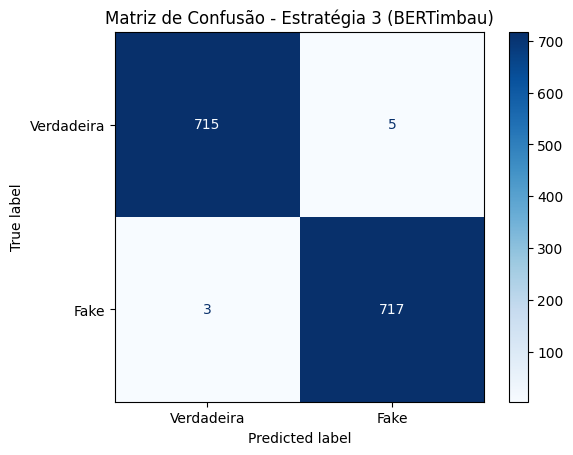

AUC-ROC: 0.9991


In [ ]:
# 6. Configuração de treino do BERTimbau
training_args = TrainingArguments(
    output_dir='./bertimbau_fake_news',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 7. Fine-tuning
print('Iniciando o fine-tuning do BERTimbau...')
trainer.train()

# 8. Avaliação final no conjunto de teste
predictions_output = trainer.predict(test_dataset)
test_logits = predictions_output.predictions
test_predictions = np.argmax(test_logits, axis=1)
test_labels = predictions_output.label_ids

print('\nRelatório de classificação - Estratégia 3 (BERTimbau):')
print(classification_report(test_labels, test_predictions, digits=4))

conf_matrix = confusion_matrix(test_labels, test_predictions)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Verdadeira', 'Fake']).plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - Estratégia 3 (BERTimbau)')
plt.show()

# 9. AUC-ROC, caso o modelo gere probabilidades suficientes
try:
    test_probabilities = torch.softmax(torch.tensor(test_logits), dim=1).numpy()[:, 1]
    auc_roc = roc_auc_score(test_labels, test_probabilities)
    print(f'AUC-ROC: {auc_roc:.4f}')
except Exception as error:
    print(f'Não foi possível calcular AUC-ROC: {error}')

### 4. Auditoria Humana e Análise de Erros

Nesta etapa, realizamos uma inspeção qualitativa para entender o comportamento do modelo BERTimbau em comparação com as Regras Heurísticas e a realidade dos dados.

**Objetivos da Auditoria:**
1. **Falsos Positivos (FP):** Por que notícias verdadeiras foram classificadas como Fake? (Ex: Linguagem informal, falta de fontes citadas no texto, temas polêmicos).
2. **Falsos Negativos (FN):** Por que Fake News passaram como verdadeiras? (Ex: Escrita muito formal, mimetismo de portais de notícias sérios).
3. **Divergência Heurística vs. ML:** Casos onde as regras simples acertaram e o Transformer errou.
4. **Coeficiente Kappa:** Medir a concordância entre a Estratégia 1 (Regras) e a Estratégia 3 (BERT).

In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# 1. Preparar DataFrame de Auditoria (alinhando os índices do conjunto de teste)
test_indices = X_test.index
df_auditoria = df.loc[test_indices].copy()
df_auditoria['pred_bert'] = test_predictions
df_auditoria['pred_heuristica'] = df_e1.loc[test_indices, 'predicao_heuristica']

# 2. Extração de Amostras para Análise Qualitativa
def get_samples(df_audit, label_real, label_pred, n=3):
    return df_audit[(df_audit['classe'] == label_real) & (df_audit['pred_bert'] == label_pred)].head(n)

print("--- AMOSTRAS PARA AUDITORIA QUALITATIVA ---\n")

print("A) FALSOS POSITIVOS (Verdadeiras que o BERT chamou de FAKE):")
display(get_samples(df_auditoria, 0, 1)[['titulo', 'pred_heuristica']])

print("\nB) FALSOS NEGATIVOS (Fakes que o BERT chamou de VERDADEIRA):")
display(get_samples(df_auditoria, 1, 0)[['titulo', 'pred_heuristica']])

# 3. Cálculo do Coeficiente Kappa de Cohen
# Compara a concordância entre o Modelo de ML e o Sistema de Regras
kappa_bert_rules = cohen_kappa_score(df_auditoria['pred_bert'], df_auditoria['pred_heuristica'])

print(f"\n--- CONCORDÂNCIA ESTATÍSTICA ---")
print(f"Coeficiente Kappa (BERT vs. Regras): {kappa_bert_rules:.4f}")

# Interpretação do Kappa:
# < 0: Sem concordância
# 0.01–0.20: Insignificante
# 0.21–0.40: Mediana
# 0.41–0.60: Moderada
# 0.61–0.80: Substancial
# 0.81–1.00: Quase perfeita"

#### Roteiro para Análise Linguística:

*   **Características indutoras de erro:** O modelo se perde em sarcasmo ou citações diretas longas?
*   **Domínios refratários:** Há algum tema (Política, Saúde, Religião) onde o erro é sistemático?
*   **Padrões informais:** As notícias verdadeiras reprovadas possuem excesso de gírias ou pontuação atípica?
*   **Divergência:** Em quantos casos o sistema de regras (Estratégia 1) foi mais conservador que o BERT?

# Conclusão Geral

Ao longo deste trabalho, foi estruturado um pipeline completo para a detecção automática de fake news em português brasileiro, combinando diferentes níveis de complexidade e interpretabilidade. A proposta parte de uma abordagem heurística, avança para modelos clássicos de aprendizado de máquina com representações vetoriais e culmina em um modelo de linguagem baseado em Transformers, permitindo uma comparação consistente entre soluções leves, intermediárias e de maior capacidade semântica.

A Estratégia 1 mostrou o valor de regras explícitas e interpretáveis, úteis como ponto de partida para analisar sinais superficiais de desinformação, como uso excessivo de maiúsculas, pontuação expressiva e padrões de clickbait. Embora limitada em generalização, essa abordagem ajuda a entender quais características do texto podem estar associadas a conteúdo suspeito e serve como baseline explicável.

A Estratégia 2 ampliou a capacidade do sistema ao explorar TF-IDF, algoritmos clássicos como Naive Bayes, Regressão Logística e SVM, além de uma versão híbrida com features numéricas. Essa etapa deve concentrar o melhor equilíbrio entre custo computacional, facilidade de treino e desempenho prático, especialmente para um dataset balanceado como o Fake.Br Corpus.

Por fim, a Estratégia 3 adiciona o BERTimbau, que permite capturar contexto linguístico de forma muito mais profunda, preservando nuances do português brasileiro. Essa etapa tem maior potencial de desempenho, mas também maior custo de processamento, exigindo GPU e maior atenção à configuração do ambiente. Em conjunto, as três estratégias permitem não apenas comparar métricas, mas também discutir trade-offs entre interpretabilidade, eficiência e poder preditivo.

Assim, o trabalho se organiza como uma investigação progressiva e fundamentada sobre fake news em português, com base em um corpus apropriado, técnicas de PLN consolidadas e critérios de avaliação claros. O resultado final esperado não é apenas identificar qual modelo obtém melhor F1-score, mas também compreender por que cada abordagem acerta ou erra, oferecendo uma análise mais completa do problema e das suas limitações.